Z-threshold for bottom layers: 11.078431372549021 (max Z: 43.13725490196079, min Z: 0.39215686274509803)


/home/pranav/anaconda3/envs/mango_orchard/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/pranav/anaconda3/envs/mango_orchard/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


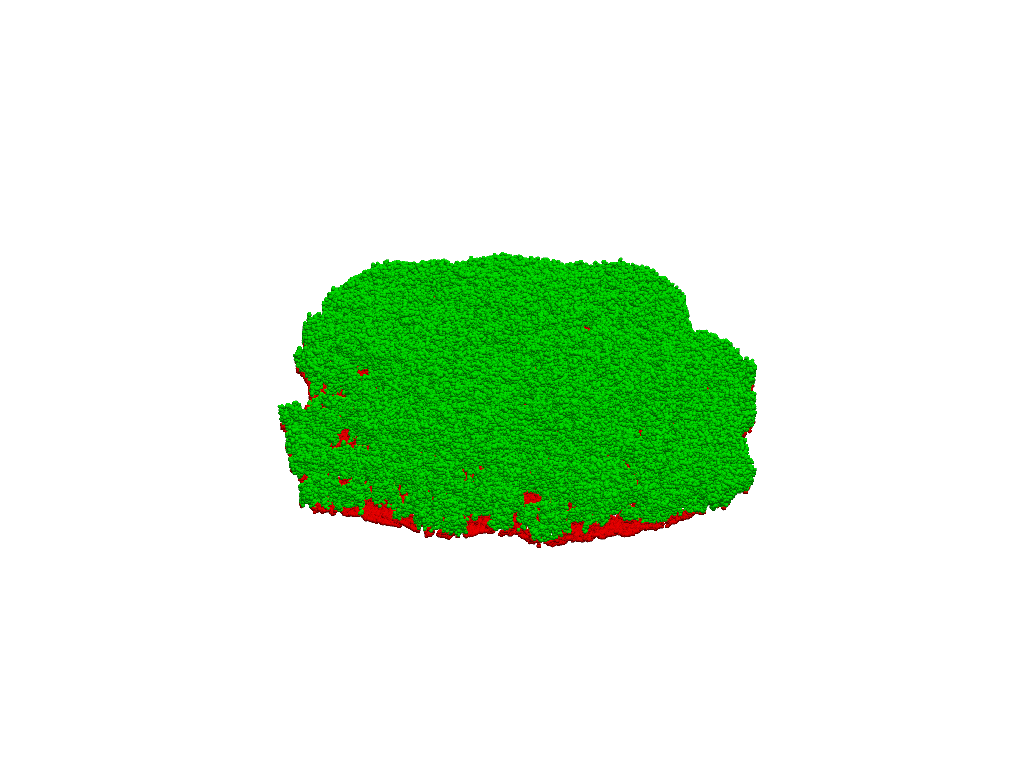

Percentage of red area: 27.01%


In [16]:
import numpy as np
import cv2
import pyvista as pv

def load_image(image_path):
    """ Load the mask image in grayscale. """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at the specified path: {image_path}")
    return image

def create_depth_colored_point_cloud(mask, scale=50, bottom_layer_percentage=25):
    """ Create a 3D point cloud from the mask, color-coding the bottom percentage as red and calculating the red area. """
    points = []
    colors = []
    red_point_count = 0
    h, w = mask.shape
    z_values = (mask.astype(float) / 255.0) * scale  

    
    unique_z_values = np.unique(z_values[z_values > 0])

    
    if len(unique_z_values) > 1:
        max_z = unique_z_values[-1]  # Highest Z-value
        min_z = unique_z_values[0]   # Minimum Z-value
    else:
        
        print("No valid points in mask.")
        return np.array([]), np.array([]), 0, 0

    # Define the threshold for the bottom percentage (bottom layers)
    z_threshold = min_z + (bottom_layer_percentage / 100.0) * (max_z - min_z)
    
    print(f"Z-threshold for bottom layers: {z_threshold} (max Z: {max_z}, min Z: {min_z})")

    # Loop over each point and assign colors based on Z-value, while counting red points
    for y in range(h):
        for x in range(w):
            z = z_values[y, x]
            if z > 0:  
                points.append([x, y, z])
                if z <= z_threshold:
                    colors.append([1, 0, 0])  # Red for the bottom percentage of layers
                    red_point_count += 1  # Count red points
                else:
                    colors.append([0, 1, 0])  

    points = np.array(points)
    colors = np.array(colors, dtype=np.float32)  

    total_point_count = len(points)

   

    return points, colors, red_point_count, total_point_count

def calculate_red_area_percentage(red_point_count, total_point_count):
    """ Calculate the percentage of red points to total points. """
    if total_point_count == 0:
        return 0
    return (red_point_count / total_point_count) * 100

def visualize_colored_point_cloud(points, colors, point_size=4):
    """ Visualize the tree point cloud using PyVista with depth-based color coding. """
    if points.size == 0:
        print("No points to display.")
        return

    point_cloud = pv.PolyData(points)
    point_cloud["colors"] = colors  

    plotter = pv.Plotter()
    # Set smaller point size for better visualization
    plotter.add_points(point_cloud, scalars="colors", rgb=True, point_size=point_size, render_points_as_spheres=True)
    plotter.view_isometric()
    plotter.show()


mask_image_path = 'DJI_5040_mask_2.png'  

try:
    mask = load_image(mask_image_path)
    points, colors, red_point_count, total_point_count = create_depth_colored_point_cloud(mask, bottom_layer_percentage=25)  # Taking only 25% for bottom layers
    red_area_percentage = calculate_red_area_percentage(red_point_count, total_point_count)
    visualize_colored_point_cloud(points, colors)

    # Output the percentage of red area
    print(f"Percentage of red area: {red_area_percentage:.2f}%")

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred: {e}")